# Stellar Coordinate Explorer - Comparison of Biased and Random Sampling

## Objective
Compare the biased (first 10,000 rows) and random (`ORDER BY random_index`) samples across multiple visualizations to reveal systematic differences due to database ordering.

## Why this matters
Demonstrate effects of biased selection of sources and why random sampling provides a better representative sample for scientific analysis.

## Datasets
- __Biased__: `sources_with_galactic_coord_biased.fits` (first 10k rows, no randomization)
- __Random__: `sources_with_galactic_coord_random.fits` (randomised, unbiased)

## Goals for Today
- Load both samples
- Add side-by-side and overlay visualization plots
- Write conclusion that picks a candidate for final analysis
- 

## Visualization plots
1. Side-by-side RA/Dec scatter plots (colour-coded by magnitude)
2. Side-by-side Aitoff projections (Galactic coordinates)
3. Overlaid histograms: magnitude distribution
4. Overlaid histograms: parallax distribution
5. Overlaid histograms: BP-RP colour index distribution

## Checkpoint
- All five comparison figures generated
- Clear conclusion stating which sample is used for final analysis

## Code
### 1. Setup and Loading

In [ ]:
from astropy.table import Table
from astropy.coordinates import Longitude, Angle
from astropy.visualization import MinMaxInterval
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as colors
import textwrap

biased = Table.read("../../data/sources_with_galactic_coord_biased.fits")
random = Table.read("../../data/sources_with_galactic_coord_random.fits")
biased.meta['data_selection'] = 'biased'
random.meta['data_selection'] = 'random'

# biased.info(), random.info()

### 2. Exploring Bias Effects through visualization
In this section, we generate plots for comparing spatial and photometric properties of both the random and biased sample sources data to demonstrate bias effects in analysis.

#### 2.1. RA/Dec Scatter Plots
Here were showcase the spatial differences with sources coloured by apparent G-band magnitude.

In [10]:
# Select the interval for colour mapping normalization
interval = MinMaxInterval()
biased_g_min, biased_g_max = interval.get_limits(biased['phot_g_mean_mag'])
random_g_min, random_g_max = interval.get_limits(random['phot_g_mean_mag'])

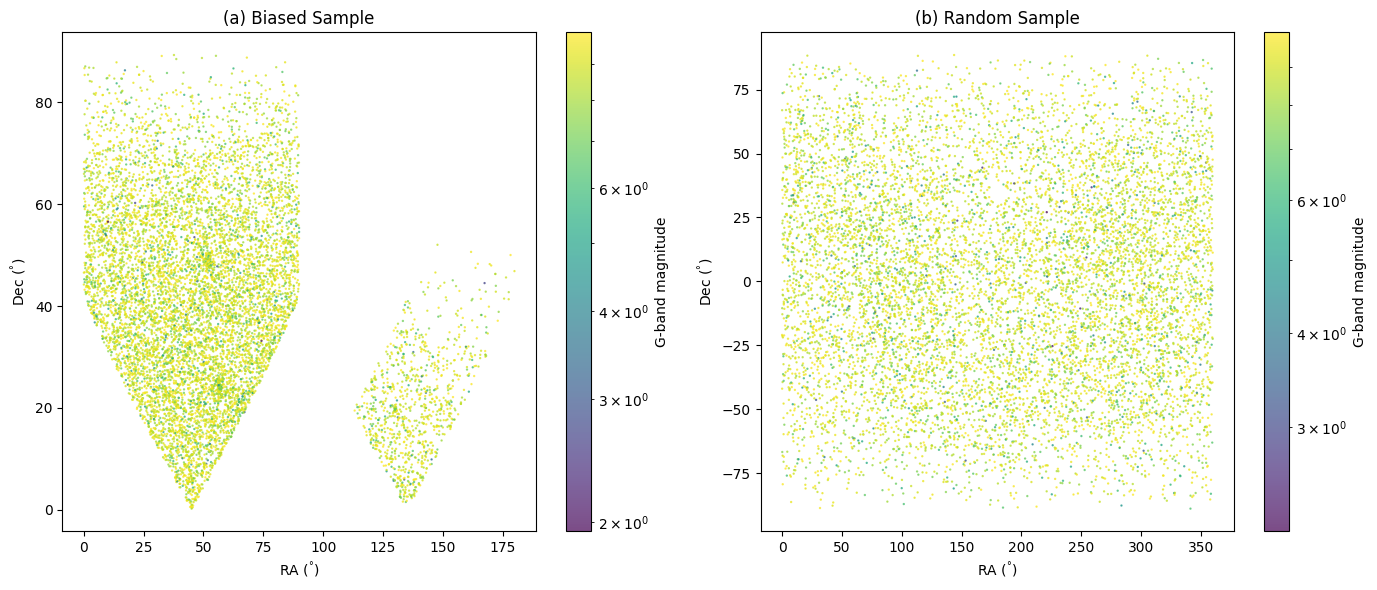

In [11]:
# RA/Dec scatter plots

# Biased
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
sc1 = ax1.scatter(biased['ra'], biased['dec'], c=biased['phot_g_mean_mag'], vmin=biased_g_min, vmax=biased_g_max, norm='log', cmap='viridis', s=0.5, alpha=0.7)
ax1.set_title('(a) Biased Sample')
ax1.set_xlabel(r'RA ($^\degree$)')
ax1.set_ylabel(r'Dec ($^\degree$)')
plt.colorbar(sc1, ax=ax1, label='G-band magnitude')

# Random
sc2 = ax2.scatter(random['ra'], random['dec'], c=random['phot_g_mean_mag'], vmin=random_g_min, vmax=random_g_max, norm='log', cmap='viridis', s=0.5, alpha=0.7)
ax2.set_title('(b) Random Sample')
ax2.set_xlabel(r'RA ($^\degree$)')
ax2.set_ylabel(r'Dec ($^\degree$)')
plt.colorbar(sc2, ax=ax2, label='G-band magnitude')

plt.tight_layout()
plt.show()

#### 2.2. Aitoff Projections
In this section, we compare the positions of both biased and random samples in the Galactic coordinates.

First we need to wrap the galactic longitude (_l_) for both the biased and random sample in the interval [$-180^{\degree}$, $180^{\degree}$] ([-$\pi$, $\pi$]) radians and define the function for formatting longitude tick labels:

In [13]:
from matplotlib.ticker import FuncFormatter

# Biased 
bias_l_wrapped = Longitude(biased['gal_l'], wrap_angle=180 * u.deg)
bias_l_rad = bias_l_wrapped.radian
bias_b_rad = Angle(biased['gal_b']).radian

# Random
rand_l_wrapped = Longitude(random['gal_l'], wrap_angle=180 * u.deg)
rand_l_rad = rand_l_wrapped.radian
rand_b_rad = Angle(random['gal_b']).radian

# Define format for longitude coordinate tickers
def coordinate_ticks(x, pos):
    """
    Determines the string value that get's displayed at each tick
    
    x: tick value (int, float)
    pos: tick position (automatic)
    
    Returns: coordinate tick value (string)
    """    
    tick_val = Angle(-x * u.radian).wrap_at(360 * u.deg).degree
    return f"${tick_val:.0f}" + r"^{\circ}$"


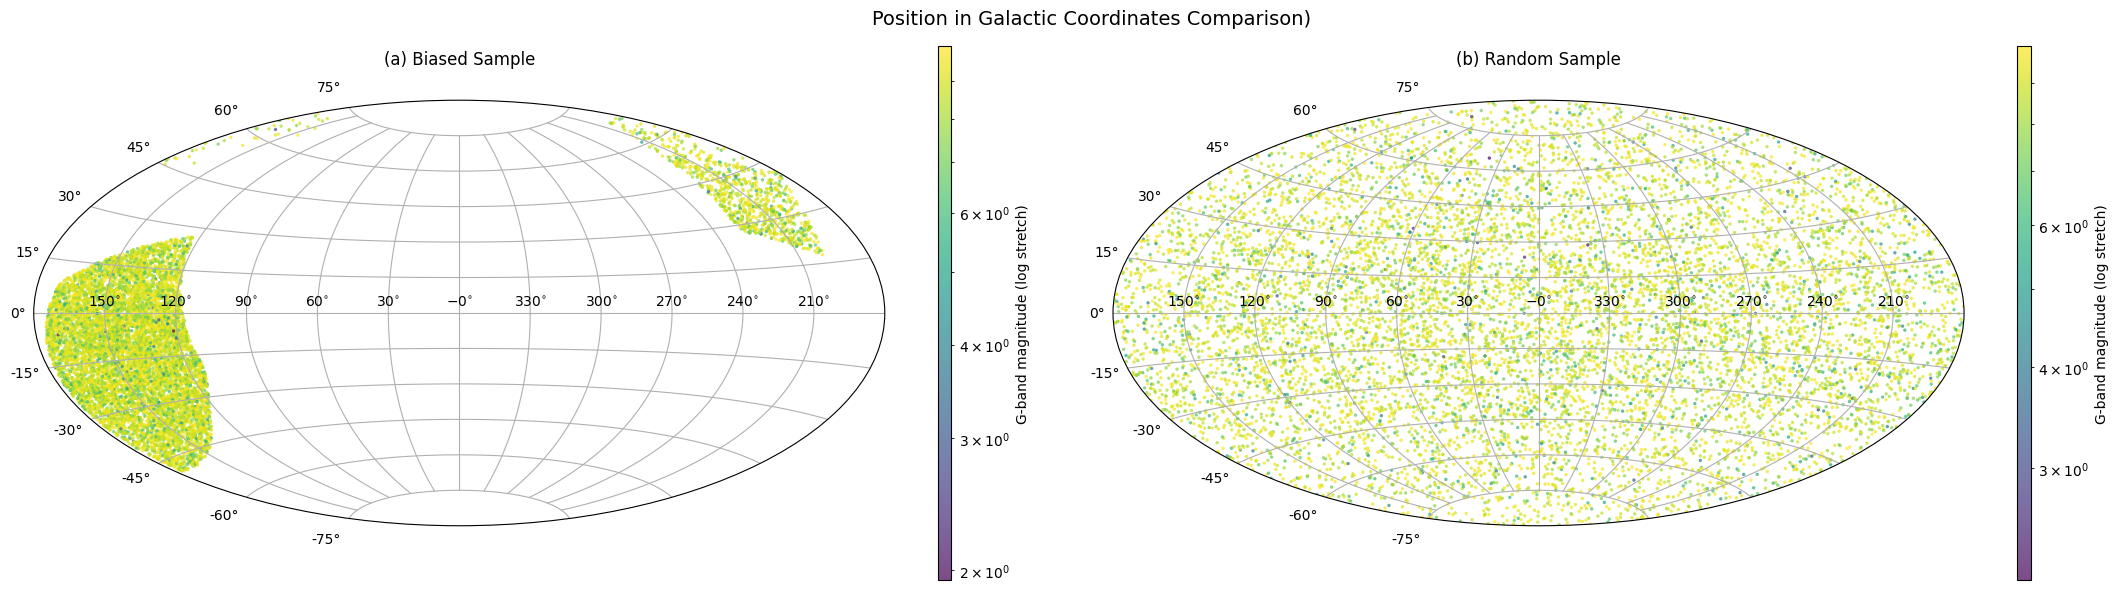

In [22]:
# Aitoff Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 6), subplot_kw={'projection': 'aitoff'})

# Normalize using log stretch for magnitude color mapping
biased_norm = colors.LogNorm(vmin=biased_min, vmax=biased_max)
random_norm = colors.LogNorm(vmin=random_min, vmax=random_max)

# Biased
sc1 = ax1.scatter(-bias_l_rad, bias_b_rad, c=biased['phot_g_mean_mag'], norm=biased_norm, cmap='viridis', s=6, alpha=0.7, linewidths=0)
ax1.set_title("(a) Biased Sample", pad=26)
ax1.xaxis.set_major_formatter(FuncFormatter(coordinate_ticks))
ax1.grid(True)


# Random
sc2 = ax2.scatter(-rand_l_rad, rand_b_rad, c=random['phot_g_mean_mag'], norm=random_norm, cmap='viridis', s=6, alpha=0.7, linewidths=0)
ax2.set_title("(b) Random Sample", pad=26)
ax2.xaxis.set_major_formatter(FuncFormatter(coordinate_ticks))
ax2.grid(True)

# Colorbars for each plot
cbar1 = fig.colorbar(sc1, ax=ax1, location='right', pad=0.05, aspect=40)
cbar1.set_label('G-band magnitude (log stretch)')

cbar2 = fig.colorbar(sc2, ax=ax2, location='right', pad=0.05, aspect=40)
cbar2.set_label('G-band magnitude (log stretch)')

plt.suptitle("Position in Galactic Coordinates Comparison)", fontsize=14)
plt.tight_layout()
plt.show()

#### 2.3. Magnitude Histograms

Here we plot an overlaid histogram for both the biased and random sample apparent G-band magnitudes:

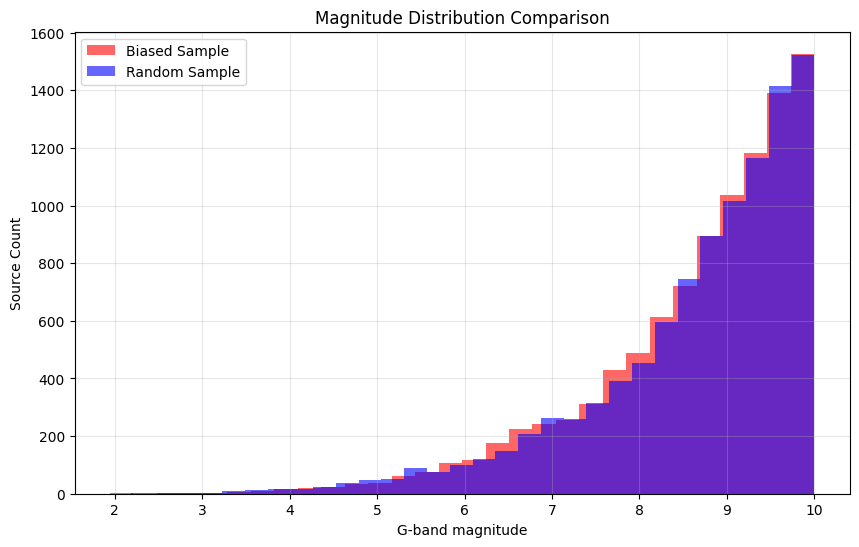

In [17]:
plt.figure(figsize=(10, 6))
plt.hist(biased['phot_g_mean_mag'], bins=30, alpha=0.6, label='Biased Sample', color='red')
plt.hist(random['phot_g_mean_mag'], bins=30, alpha=0.6, label='Random Sample', color='blue')
plt.xlabel('G-band magnitude')
plt.ylabel('Source Count')
plt.title('Magnitude Distribution Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### 2.4. Parallax Histograms

We now compare the distance distribution differences between the random and biased sample sources:

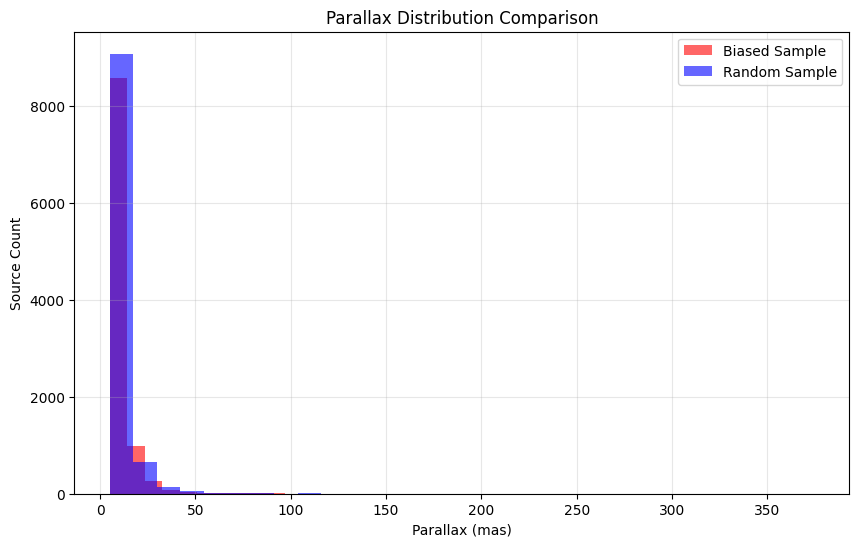

In [18]:
plt.figure(figsize=(10, 6))
plt.hist(biased['parallax'], bins=30, alpha=0.6, label='Biased Sample', color='red')
plt.hist(random['parallax'], bins=30, alpha=0.6, label='Random Sample', color='blue')
plt.xlabel('Parallax (mas)')
plt.ylabel("Source Count")
plt.title('Parallax Distribution Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### 2.5. BP-RP (`bp_rp`) Histograms

Now we compare colour index distribution for both random and biased sample sources:

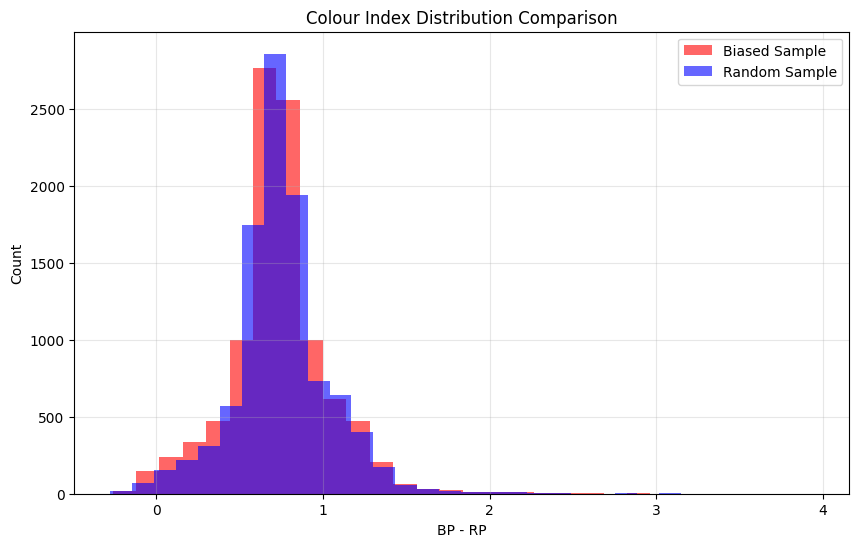

In [21]:
# Fill masked columns with NaN and drop
bp_rp_b_filled = biased['bp_rp'].filled(np.nan)
bp_rp_b_clean = bp_rp_b_filled[~np.isnan(bp_rp_b_filled)]
bp_rp_r_filled = random['bp_rp'].filled(np.nan)
bp_rp_r_clean = bp_rp_r_filled[~np.isnan(bp_rp_r_filled)]

plt.figure(figsize=(10, 6))
plt.hist(bp_rp_b_clean, bins=30, alpha=0.6, label='Biased Sample', color='red')
plt.hist(bp_rp_r_clean, bins=30, alpha=0.6, label='Random Sample', color='blue')
plt.xlabel('BP - RP')
plt.ylabel('Count')
plt.title('Colour Index Distribution Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()